In [ ]:
import numpy as np
from enum import Enum
import math

class Modulation(Enum):
    BPSK = 1
    QPSK = 2
    QAM8 = 3
    QAM16 = 4

def get_eligible_modulation(reach):
    if reach > 2500:
        return [Modulation.BPSK]
    elif reach > 1250:
        return [Modulation.BPSK, Modulation.QPSK]
    elif reach > 625:
        return [Modulation.BPSK, Modulation.QPSK, Modulation.QAM8]
    else:
        return [Modulation.BPSK, Modulation.QPSK, Modulation.QAM8, Modulation.QAM16]
    
data_rate = 100
reach = 500
modulations = get_eligible_modulation(reach)
num_slots = [int(math.ceil(data_rate/(modulation.value * 12.5))) + 1 for modulation in modulations]
print(num_slots)
d = zip(modulations, num_slots)
for o in d:
    print(o)
# num_slots = int(np.ceil(data_rate / (modulations * 12.5))) + 1

In [ ]:
import numpy as np

alpha_dB: float = 0.2
L_span: float = 80.0
NF_dB: float = 5.0
G_dB = alpha_dB * L_span
G_lin = 10**(G_dB / 10)
NF_lin = 10**(NF_dB / 10)
n_sp = (NF_lin / 2) * (G_lin / (G_lin - 1))
alpha = alpha_dB * (np.log(10) / 10)
al = 10**(alpha_dB/10)
G_l = np.e**(alpha*L_span)
print(n_sp)
print(alpha, G_lin, G_l)

In [ ]:
from data.utility import read_network_file

filepath = "data/nsf/network.txt"
# def generate_request_set(filepath):
nodedf, adjacent = read_network_file(filepath)

[0.7427813527082074, 0.3713906763541037, 0, 0, 0, 0, 0.7427813527082074, 0.4951875684721383, 0.24759378423606915, 0, 0, 0.7427813527082074, 0.5570860145311556, 0.3713906763541037, 0.18569533817705186, 0, 0]
[0.7427813527082074, 0.3713906763541037, 0, 0, 0, 0, 0.7427813527082074, 0.4951875684721383, 0.24759378423606915, 0, 0, 0.7427813527082074, 0.5570860145311556, 0.3713906763541037, 0.18569533817705186, 0, 0]
LENGTH [0, 0, 4, 3, 2, 1, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1]
REQ = 1 [0, 0, 0.8944271909999159, 0.6708203932499369, 0.4472135954999579, 0.22360679774997896, 0, 0, 0, 0.8944271909999159, 0.4472135954999579, 0, 0, 0, 0, 0.8944271909999159, 0.4472135954999579]
LENGTH [0, 0, 3, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]
REQ = 2 [0, 0, 0.9486832980505138, 0.6324555320336759, 0.31622776601683794, 0, 0, 0, 0, 0.9486832980505138, 0, 0, 0, 0, 0, 0.9486832980505138, 0]
LENGTH [0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
REQ = 3 [0, 0, 1.0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
LE

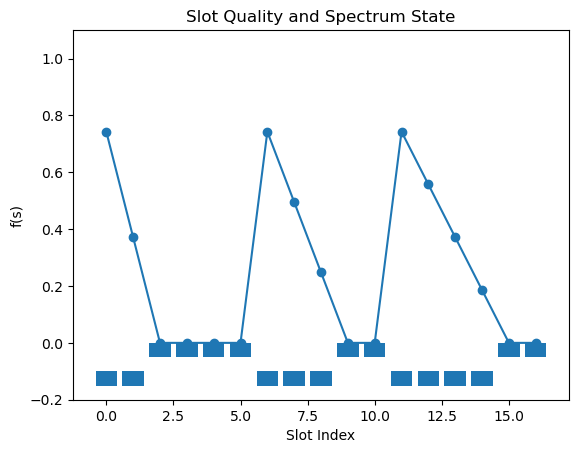

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import math

def F(slot_index, spectrum):
    available_block = []
    n = len(spectrum)
    i = 0
    if spectrum[slot_index] == 1:
        return 0
    
    a, b = 0, 0
    while i < n:
        if spectrum[i] == 0:
            start = i
            while i < n and spectrum[i] == 0:
                i += 1
            available_block.append((start, i - 1))
            if start <= slot_index and slot_index <= i-1:
                a = start
                b = i-1
        else:
            i += 1

    max_slot = max([e - s  + 1 for s, e in available_block])
    sum_square = sum([(e - s + 1)**2 for s, e in available_block])
    sum_square = math.sqrt(sum_square)

    # print("AV BLOCK", available_block)
    # print("SUM SQURE", sum_square)
    # print("MAX SLOT", max_slot)
    f = (b - slot_index + 1) / (b - a + 1) * max_slot / sum_square
    return f

def F2(spectrum):
    length = [0 for i in range(len(spectrum))]
    for i in range(len(spectrum)-1, -1, -1):
        if i == len(spectrum) - 1:
            length[i] = 1 if spectrum[i] == 0 else 0
        else:
            length[i] = 0 if spectrum[i] == 1 else length[i+1]+1
    
    max_segment = [0 for i in range(len(spectrum))]

    current_max = 0

    for i in range(len(length)):
        if length[i] == 0:
            current_max = 0
            continue
        
        if current_max == 0:
            current_max = length[i]
        
        max_segment[i] = current_max
    # print("LENGTH", length)
    # print("MAX SEGMENT", max_segment)
    set_max = set(max_segment)
    max_slot = max(set_max)
    sum_square = math.sqrt(sum([i**2 for i in set_max]))
    # print("SET", set_max)
    # print("SUM", sum_square)
    fr = [(length[i])/(max_segment[i]) * max_slot / sum_square if max_segment[i] > 0 else 0 for i in range(len(spectrum))]
    return fr

def F3(spectrum, required=1):
    length = [0 for i in range(len(spectrum))]
    fea_length = [0 for i in range(len(spectrum))]
    for i in range(len(spectrum)-1, -1, -1):
        if i == len(spectrum) - 1:
            length[i] = 1 if spectrum[i] == 1 else 0
        else:
            length[i] = 0 if spectrum[i] == 0 else length[i+1]+1

    for i in range(len(fea_length)):
        fea_length[i] = max(length[i]-required+1, 0)
    
    max_segment = [0 for i in range(len(spectrum))]

    current_max = 0

    for i in range(len(length)):
        if fea_length[i] == 0:
            current_max = 0
            continue
        
        if current_max == 0:
            current_max = fea_length[i]
        
        max_segment[i] = current_max
    print("LENGTH", fea_length)
    # print("MAX SEGMENT", max_segment)
    set_max = set(max_segment)
    max_slot = max(set_max)
    sum_square = math.sqrt(sum([i**2 for i in set_max]))
    # print("SET", set_max)
    # print("SUM", sum_square)
    fr = [(fea_length[i])/(max_segment[i]) * max_slot / sum_square if max_segment[i] > 0 else 0 for i in range(len(spectrum))]
    return fr


spectrum = [0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]
val = [F(i, spectrum) for i in range(len(spectrum))]
print(val)
fr = F2(spectrum)
print(fr)

print("REQ = 1", F3(spectrum, 1))
print("REQ = 2", F3(spectrum, 2))
print("REQ = 3", F3(spectrum, 3))
print("REQ = 4", F3(spectrum, 4))
print("REQ = 5", F3(spectrum, 5))


fig, ax = plt.subplots()

# plot function values
x = np.arange(len(spectrum))
ax.plot(x, val, marker='o')
ax.set_xlabel("Slot Index")
ax.set_ylabel("f(s)")
ax.set_title("Slot Quality and Spectrum State")

# draw spectrum rectangles
for i, slot in enumerate(spectrum):

    if slot == 1:
        height = -0.05
    else:
        height = -0.15

    rect = plt.Rectangle((i - 0.4, height), 0.8, 0.05)
    ax.add_patch(rect)

ax.set_ylim(-0.2, 1.1)

plt.show()

In [58]:
from custom_env.CustomRLenv.CustomRMSAEnv import CustomRMSAEnv
from custom_env.CustomRLenv.utils import modulations
from env import constant
import math

granularity = []
for bit_rate in constant.bit_rates:
    for m in modulations:
        nbslot = math.ceil(bit_rate/(m.spectral_efficiency * 12.5))
        granularity.append(nbslot)



print(set(granularity))
spectrum = [0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]

fs, val, l = CustomRMSAEnv.rle(spectrum)
print(val, l, l/3)
s = np.floor(np.dot(val, l/3).flatten())
# np.floor(s)
print(s)
0.666*2+1.333

{32, 2, 3, 4, 6, 7, 8, 11, 16}
[0 1 0 1 0 1] [2 4 3 2 4 2] [0.66666667 1.33333333 1.         0.66666667 1.33333333 0.66666667]
[2.]


2.665

In [1]:
from custom_env.optical_rl_gym.envs.rmsa_env import RMSAEnv
from custom_env.CustomRLenv.utils import get_topology, read_sndlib_txt_file
from custom_env.CustomRLenv.CustomRMSAEnv import CustomRMSAEnv
from custom_env.optical_rl_gym.utils import Path, Service, Modulation


# topology = get_topology('./data/nsf/nsfnet_chen.txt', 'NSFNET')

topology = get_topology(f'./data/germany/sndlib_germany.txt', 'Germany', sndformat=True, k_paths=3)
env = CustomRMSAEnv(topology, mean_service_holding_time=25)


env._new_service = False
env._next_service()

# for i in range(100):

#     src, dest = env.current_service.source, env.current_service.destination
#     selected_path: Path = env.k_shortest_paths[src, dest][0]
#     selected_path.current_modulation = env.current_service.best_modulation

#     slots = env.get_number_slots(selected_path)


# graph = read_sndlib_txt_file(f'./data/germany/sndlib_germany.txt')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


	 Path(path_id=0, node_list=['1', '47', '43', '25', '46', '48', '2'], hops=6, length=487, best_modulation=Modulation(name='16QAM', maximum_length=500, spectral_efficiency=4, minimum_osnr=22.4, inband_xt=-23), current_modulation=None)
	 Path(path_id=1, node_list=['1', '47', '43', '24', '25', '46', '48', '2'], hops=7, length=506, best_modulation=Modulation(name='8QAM', maximum_length=1000, spectral_efficiency=3, minimum_osnr=18.6, inband_xt=-20), current_modulation=None)
	 Path(path_id=2, node_list=['1', '30', '29', '24', '25', '46', '48', '2'], hops=7, length=511, best_modulation=Modulation(name='8QAM', maximum_length=1000, spectral_efficiency=3, minimum_osnr=18.6, inband_xt=-20), current_modulation=None)
	 Path(path_id=3, node_list=['1', '30', '29', '17', '19', '50', '38', '3'], hops=7, length=534, best_modulation=Modulation(name='8QAM', maximum_length=1000, spectral_efficiency=3, minimum_osnr=18.6, inband_xt=-20), current_modulation=None)
	 Path(path_id=4, node_list=['1', '30', '29', 

In [2]:

from custom_env.CustomRLenv.osnr import calculate_osnr, compute_ase_nli
from env import constant
from custom_env.CustomRLenv.utils import modulations
# env.set_launch_power(2)

env.customreset()
# env._new_service = False
# env._next_service()


for i in range(100):

    src, dest = env.current_service.source, env.current_service.destination
    selected_path: Path = env.k_shortest_paths[src, dest][0]
    selected_path.current_modulation = selected_path.best_modulation
    # selected_path.current_modulation = modulations[0]

    slots = env.get_number_slots(selected_path)

    slot_index, length = env.get_available_blocks(0, selected_path.current_modulation)

    # print(slot_index, length)
    if len(slot_index) == 0:
        continue

    # initial_slot = slot_index[0]
    for initial_slot in slot_index:
        env.current_service.path = selected_path
        env.current_service.initial_slot = initial_slot
        env.current_service.number_slots = slots
        env.current_service.center_frequency = constant.frequency_start \
            + constant.frequency_slot_bandwidth * initial_slot \
            + constant.frequency_slot_bandwidth * (slots / 2.0)
        env.current_service.bandwidth = constant.frequency_slot_bandwidth * slots
        env.current_service.launch_power = env.launch_power

        osnr, ase, nli = compute_ase_nli(env, env.current_service)
        if osnr >= selected_path.current_modulation.minimum_osnr + constant.osnr_margin:
            env._provision_path(selected_path, initial_slot, slots)
        else:
            print("%s: OSNR violated, slot %s"%(i, initial_slot))
            print(osnr, selected_path.current_modulation.minimum_osnr + constant.osnr_margin, selected_path.current_modulation)
        env._new_service = False
        env._next_service() 



1: OSNR violated, slot 0
24.3105401717078 24.4 Modulation(name='16QAM', maximum_length=500, spectral_efficiency=4, minimum_osnr=22.4, inband_xt=-23)
4: OSNR violated, slot 0
30.33114008498742 32.4 Modulation(name='64QAM', maximum_length=125, spectral_efficiency=6, minimum_osnr=30.4, inband_xt=-29)
5: OSNR violated, slot 3
24.529855925298044 28.4 Modulation(name='32QAM', maximum_length=250, spectral_efficiency=5, minimum_osnr=26.4, inband_xt=-26)
7: OSNR violated, slot 3
26.902942868431108 28.4 Modulation(name='32QAM', maximum_length=250, spectral_efficiency=5, minimum_osnr=26.4, inband_xt=-26)
8: OSNR violated, slot 3
25.276910256180205 28.4 Modulation(name='32QAM', maximum_length=250, spectral_efficiency=5, minimum_osnr=26.4, inband_xt=-26)
11: OSNR violated, slot 3
23.993408147769006 28.4 Modulation(name='32QAM', maximum_length=250, spectral_efficiency=5, minimum_osnr=26.4, inband_xt=-26)
14: OSNR violated, slot 0
27.745088870581448 28.4 Modulation(name='32QAM', maximum_length=250, s

In [3]:
# from custom_env.CustomRLenv.osnr import calculate_osnr, compute_ase_nli
# env.set_launch_power(0)
# e = list(env.topology.edges)[0]
# print(e)
# service = env.topology[e[0]][e[1]]["running_services"][0]
# print(calculate_osnr(env, service))
# print(compute_ase_nli(env, service))
e = list(env.topology.edges)[0]
# env.topology.graph["available_slots"][env.topology[e[0]][e[1]]["id"]]
# print(e)
env.compute_fragmentation_abp()
# env.topology.graph["running_services"]


Edge, Numerator, denominator ('1', '30') 158.0 162.0
Edge, Numerator, denominator ('1', '49') 153.0 155.0
Edge, Numerator, denominator ('1', '47') 162.0 162.0
Edge, Numerator, denominator ('2', '48') 154.0 155.0
Edge, Numerator, denominator ('2', '35') 139.0 150.0
Edge, Numerator, denominator ('2', '50') 153.0 153.0
Edge, Numerator, denominator ('3', '32') 168.0 168.0
Edge, Numerator, denominator ('3', '9') 168.0 168.0
Edge, Numerator, denominator ('3', '38') 145.0 147.0
Edge, Numerator, denominator ('4', '32') 168.0 168.0
Edge, Numerator, denominator ('4', '12') 168.0 168.0
Edge, Numerator, denominator ('4', '44') 168.0 168.0
Edge, Numerator, denominator ('4', '33') 154.0 162.0
Edge, Numerator, denominator ('4', '21') 164.0 164.0
Edge, Numerator, denominator ('5', '36') 151.0 155.0
Edge, Numerator, denominator ('5', '45') 131.0 135.0
Edge, Numerator, denominator ('5', '23') 156.0 162.0
Edge, Numerator, denominator ('5', '6') 151.0 155.0
Edge, Numerator, denominator ('6', '33') 136.0 1

0.9813390634186487

In [4]:
spec = env.topology.graph["available_slots"][env.topology['50']['2']['index']]
print(spec)

[1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [4]:
from math import log, exp, asinh, log10, ceil, pi
from env import constant

import numpy as np

# env.customreset()
# env._new_service = False
# env._next_service()
env.set_launch_power(0)
src, dest = env.current_service.source, env.current_service.destination
selected_path: Path = env.k_shortest_paths[src, dest][0]
selected_path.current_modulation = selected_path.best_modulation
initial_slot = 0

slots = env.get_number_slots(selected_path)
env.current_service.path = selected_path
env.current_service.initial_slot = initial_slot
env.current_service.number_slots = slots
env.current_service.center_frequency = constant.frequency_start \
    + constant.frequency_slot_bandwidth * initial_slot \
    + constant.frequency_slot_bandwidth * (slots / 2.0)
env.current_service.bandwidth = constant.frequency_slot_bandwidth * slots
env.current_service.launch_power = env.launch_power



current_service = env.current_service


beta_2: float = -21.3e-27  
gamma: float = 1.3e-3  
h_plank: float = 6.626e-34  
acc_gsnr: float = 0
acc_ase: float = 0
acc_nli: float = 0
gsnr: float = 0
ase: float = 0
nli: float = 0
l_eff_a: float = 0
l_eff: float = 0
phi: float = 0
sum_phi: float = 0
power_ase: float = 0
power_nli_span: float = 0
phi_modulation_format = np.array((1, 1, 2/3, 17/25, 69/100, 13/21))
service: Service

attenuation_normalized = constant.attenuation_db_km / (2 * 10 * np.log10(np.exp(1)) * 1e3)
noise_figure_normalized = 10 ** (constant.noise_figure_db / 10)

print("noise_figure_normalized", noise_figure_normalized)
print("attenuation_normalized", attenuation_normalized)

l_eff_a = 1 / (2 * attenuation_normalized)
l_eff = (1 - np.exp(-2 * attenuation_normalized * constant.fiber_span * 1e3)) / (2 * attenuation_normalized)


# print("#"*30)
# print("Service:", current_service)
# acc_gsnr = 0
for i in range(len(current_service.path.node_list)-1):
    src, dst = current_service.path.node_list[i], current_service.path.node_list[i+1]
    nb_span = ceil(env.topology[src][dst]["length"] / constant.fiber_span)

    sum_phi = asinh(
            pi ** 2 * \
            abs(beta_2) * \
            (current_service.bandwidth) ** 2 / \
            (4 * attenuation_normalized)
        )
    
    for service in env.topology[src][dst]["running_services"]:
        if service.service_id != current_service.service_id:
            d_frequency = service.center_frequency - current_service.center_frequency
            # phi = asinh(pi ** 2 * abs(beta_2) * l_eff_a * service.bandwidth * \
            #             (d_frequency + (service.bandwidth / 2))) - \
            #         asinh(pi ** 2 * abs(beta_2) * l_eff_a * service.bandwidth * \
            #             (d_frequency - (service.bandwidth / 2))
            #         ) 
            phi = np.log((d_frequency + service.bandwidth/2) / (d_frequency - service.bandwidth/2))
            # - \
            #     (phi_modulation_format[service.path.current_modulation.spectral_efficiency - 1] * \
            #         (service.bandwidth / abs(service.center_frequency - current_service.center_frequency)) * \
            #         5 / 3 * (l_eff / (constant.fiber_span * 1e3)))
            
            sum_phi += phi

    # print(nb_span, current_service.launch_power, current_service.bandwidth, sum_phi)
    power_nli_span = nb_span * (current_service.launch_power / (current_service.bandwidth)) ** 3 * \
        (8 / (27 * pi * abs(beta_2))) * gamma ** 2 * l_eff * sum_phi * current_service.bandwidth
    power_ase = nb_span * h_plank * current_service.center_frequency * \
        (exp(2 * attenuation_normalized * constant.fiber_span * 1e3) - 1) * noise_figure_normalized

    print(current_service.launch_power, power_ase, power_nli_span)
    acc_gsnr = acc_gsnr + 1 / (env.current_service.launch_power / (power_ase + power_nli_span))
    acc_ase = acc_ase + 1 / (env.current_service.launch_power / power_ase)
    acc_nli = acc_nli + 1 / (env.current_service.launch_power / power_nli_span)

gsnr = 10 * np.log10(1 / acc_gsnr)
ase = 10 * np.log10(1 / acc_ase)
nli = 10 * np.log10(1 / acc_nli)

print("OSNR:", gsnr, selected_path.current_modulation.minimum_osnr + constant.osnr_margin)

noise_figure_normalized 2.8183829312644537
attenuation_normalized 2.3025850929940457e-05
0.001 1.3894353045549034e-17 2.9231829426848606e-07
OSNR: 35.341440041524265 32.4


In [17]:
import math
from custom_env.CustomRLenv import utils
def compute_granularity():
    granularity = []
    for bit_rate in constant.bit_rates:
        for m in utils.modulations:
            nbslot = math.ceil(bit_rate/(m.spectral_efficiency * 12.5))
            granularity.append(nbslot)
    return set(granularity)

print(constant.bit_rates)
print(compute_granularity())

[100, 200, 400]
{32, 2, 3, 4, 6, 7, 8, 11, 16}


In [38]:
import random
import functools
import numpy as np

current_time = 0
rng = random.Random()
mean_service_holding_time = 200
load = 200
bit_rates = [100, 200, 400]
bit_rate_function = functools.partial(rng.choices, bit_rates, None, k=1)
mean_service_inter_arrival_time = 1 / float(load / float(mean_service_holding_time))

time_interval = []
end_time = 0
bitrate = []
for i in range(2000):
    at = current_time + rng.expovariate(1 / mean_service_inter_arrival_time)
    current_time = at
    ht = rng.expovariate(1 / mean_service_holding_time)
    br = bit_rate_function()
    time_interval.append((at, at+ht))
    bitrate.append(br)
    end_time = max(end_time, at + ht)

time_interval = np.array(time_interval)
x = np.arange(0, 2000, 0.5)
arx = np.array(x).reshape(-1, 1)
check = np.where(
    (arx >= time_interval[:, 0]) & (arx <= time_interval[:, 1]),
    1, 0
)

br_count = np.dot(check, bitrate).flatten()

count = check.sum(axis=1)
# print(count)


In [36]:
br_count = np.dot(check, bitrate).flatten()
print(br_count)

[    0     0   200 ... 31700 31300 31300]


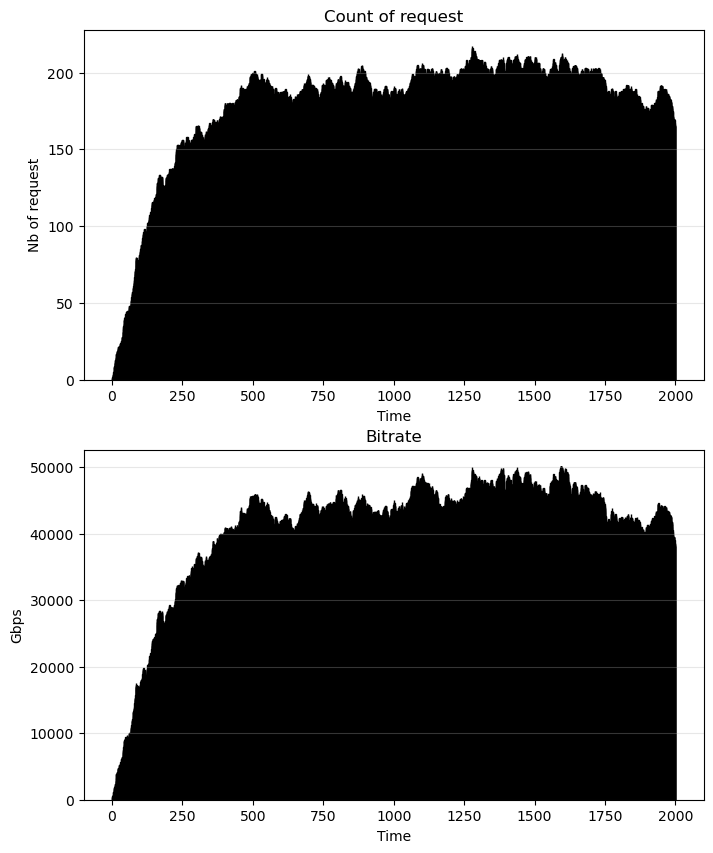

In [41]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(8, 10))
# plt.figure(figsize=(8, 5))
axs[0].bar(x, count, color='skyblue', edgecolor='black')
axs[0].set_title('Count of request')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Nb of request')
axs[0].grid(axis='y', alpha=0.3)

axs[1].bar(x, br_count, color='skyblue', edgecolor='black')
axs[1].set_title('Bitrate')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Gbps')
axs[1].grid(axis='y', alpha=0.3)

plt.show()


In [20]:
# -*- coding: utf-8 -*-

import math
import numpy as np

space = 12.5 * 10**12
ref_bw = 12.5e+9    # Mohammad, 12.5 Hz
#alpha = 0.0507                  # unit (km^-1)
alpha = 0.046/2
#h = 6.62607004 * 10**(-34)      # unit (m^2 kg s^-1)
h = 6.62607004e-31  # Mohammad, Planck's constant in milli-Joules-seconds to be consistent with Power in milli-Watts

v = 193.55 * 10**12             # unit (Hz)
nsp = 1.58                      # unitless

#v = 191 * 10**12
#v = 193.55 * 10**3             # unit (GHz)
hvn_sp = h * v * nsp * 10**9      # unit (W GHz^-1)

fiber_span = 80                # unit (km)

#gamma = 1.3                     # unit (W^-1 km^-1)
gamma = 1.3e-3#Mohammad, in 1/(mW Km)
beta2 = -21.3 * 10**-24         # unit (s^2 km^-1)
#beta2 = -8.87 * 10**-24         # unit (s^2 km^-1)
mu = 3 * gamma**2 / (2 * math.pi * alpha * np.abs(beta2)) * 10**-18
rho = math.pi**2 * np.abs(beta2) / (2 * alpha) * 10**18

#mu = 7.47 * 10**5               # unit (W^-2 GHz^2)
#rho = 2.073 * 10**-3            # unit (GHz^-2)

#space = 12.5 * 10**9           # unit (Hz)
space = 12.5                    # unit (GHz)


def approximate_XCI(nb_channel, bandwidth, used_bandwidth, nb_span, G):
    L_eff = (1 - np.exp(-2 * alpha * fiber_span)) / (2 * alpha)
    print("L_eff", L_eff)
    L_eff_a = 1/(2 * alpha)
    print("L_eff_a", L_eff_a)
    d = np.pi * L_eff_a * abs(beta2)# added by mohammad, denominator: Pi*|beta2|*Leff_a
    print("d", d)
    coeff=nb_span * 8/27 * (gamma**2 * G**3 * L_eff**2)/d
    print("coeff", coeff)
    Nch_factor = nb_channel ** (2 * (bandwidth/used_bandwidth))
    print("Nch_factor", Nch_factor)
    #arcsinhCoeff=np.arcsinh(.5*math.pi**2 * np.abs(beta2) * L_eff_a * bandwidth**2 * math.pow(nb_channel, 2 * bandwidth/used_bandwidth))
    arcsinhCoeff=np.arcsinh(.5*math.pi**2 * np.abs(beta2) * L_eff_a * bandwidth**2 * Nch_factor)

    print("arcsinhCoeff", arcsinhCoeff)
    G_NLI = (coeff)* np.arcsinh(.5*math.pi**2 * np.abs(beta2) * L_eff_a * bandwidth**2 * math.pow(nb_channel, 2 * bandwidth/used_bandwidth))
    den=G_NLI*coeff
    print("den", den)
    print("G_NLI", G_NLI)
    return G_NLI
#%%
    
#G = 4E-05 # W/GHz
G = 4 * 1e-11    #Mohammad, in mW/(Hz)
GOSNR_list=[]
for nb_channel in range(1,89):
    #nb_channel = 1
    print(nb_channel)
    #bandwidth = 35 #GHz
    bandwidth =  35e+9  # Mohammad, channel bandwidth in GHz

    used_bandwidth = 50e+9 #Mohammad, in Hz
    nb_span = 10
    G_NLI = approximate_XCI(nb_channel, bandwidth, used_bandwidth, nb_span, G)
    gnli_power =G_NLI*ref_bw#Mohammad, in mW
    print("G_NLI", G_NLI)
    print("gnli_power", gnli_power)
    print("SNR without ASE", G/G_NLI)

    #The followuing is written by Mohammad

    # ASE
    EDFA_NF = 5.01  # Amp Noise Figure (NOT in dB)
    fcns = 193.41  # center freq of span in THz
    fcut = 193.71895e+12     # channel under investigation in THz

    EDFA_Gain = np.e**(2 * alpha * fiber_span)
    ASE = nb_span * EDFA_NF * EDFA_Gain * h * fcut * ref_bw
    print("ASE", ASE)

    OSNR = (G * ref_bw) / ASE
    OSNR_dB = 10 * np.log10(OSNR)
    print("OSNR", OSNR)
    print("OSNR_dB", OSNR_dB)
    #%%
    GOSNR = (G * ref_bw) / (ASE + gnli_power)
    GOSNR_dB = 10 * np.log10(GOSNR)
    print("GOSNR_dB", GOSNR_dB)
    # Optimal Power
    p_opt = np.power(ASE/(2*gnli_power), 1/3)
    GOSNR_optimal = p_opt/(ASE + gnli_power)
    GOSNR_optimal_dB = 10 * np.log10(GOSNR_optimal)
    GOSNR_list.append(GOSNR_optimal_dB)

    print("GOSNR_optimal_dB", GOSNR_optimal_dB)
print("GOSNR_optimal_dB", GOSNR_list)


1
L_eff 21.190804894886366
L_eff_a 21.73913043478261
d 1.454693989597013e-21
coeff 9.892730152351973e-14
Nch_factor 1.0
arcsinhCoeff 1.752946095338423
den 1.715540151577638e-26
G_NLI 1.7341422692802074e-13
G_NLI 1.7341422692802074e-13
gnli_power 0.0021676778366002594
SNR without ASE 230.6615824352338
ASE 0.00318698163539108
OSNR 156.88825892422946
OSNR_dB 21.95590443426232
GOSNR_dB 19.702381471209897
GOSNR_optimal_dB 22.2671975213645
2
L_eff 21.190804894886366
L_eff_a 21.73913043478261
d 1.454693989597013e-21
coeff 9.892730152351973e-14
Nch_factor 2.6390158215457884
arcsinhCoeff 2.6974226045370373
den 2.639862569740358e-26
G_NLI 2.668487393353934e-13
G_NLI 2.668487393353934e-13
gnli_power 0.0033356092416924176
SNR without ASE 149.8976540028743
ASE 0.00318698163539108
OSNR 156.88825892422946
OSNR_dB 21.95590443426232
GOSNR_dB 18.84549865641422
GOSNR_optimal_dB 20.786379935774853
3
L_eff 21.190804894886366
L_eff_a 21.73913043478261
d 1.454693989597013e-21
coeff 9.892730152351973e-14
Nch_

In [12]:
max_hp = 96.1
max_hp - 91.2

4.8999999999999915